In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import time,requests,joblib,pickle
import seaborn as sns
bank = pd.read_csv("European_Bank.csv")

In [5]:
bank.head()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [6]:
bank.tail()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9995,2025,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,2025,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,2025,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,2025,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1
9999,2025,15628319,Walker,792,France,Female,28,4,130142.79,1,1,0,38190.78,0


In [8]:
bank.columns

Index(['Year', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender',
       'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [9]:
bank.shape

(10000, 14)

In [10]:
bank.isnull()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9996,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9997,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9998,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [11]:
bank.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
9995    False
9996    False
9997    False
9998    False
9999    False
Length: 10000, dtype: bool

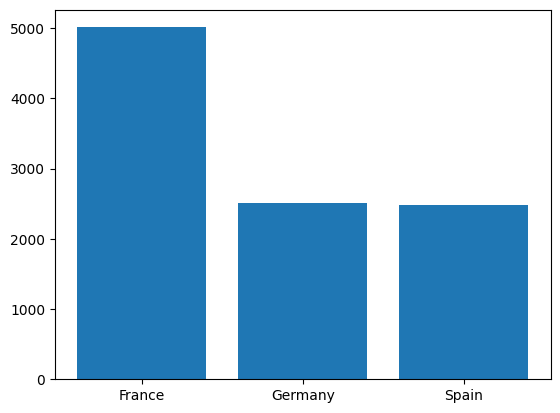

In [15]:
counts = bank["Geography"].value_counts()
plt.bar(counts.index,counts.values)
plt.show()

In [ ]:
import matplotlib.pyplot as plt

counts = df["Geography"].value_counts()

plt.bar(counts.index, counts.values)
plt.show()

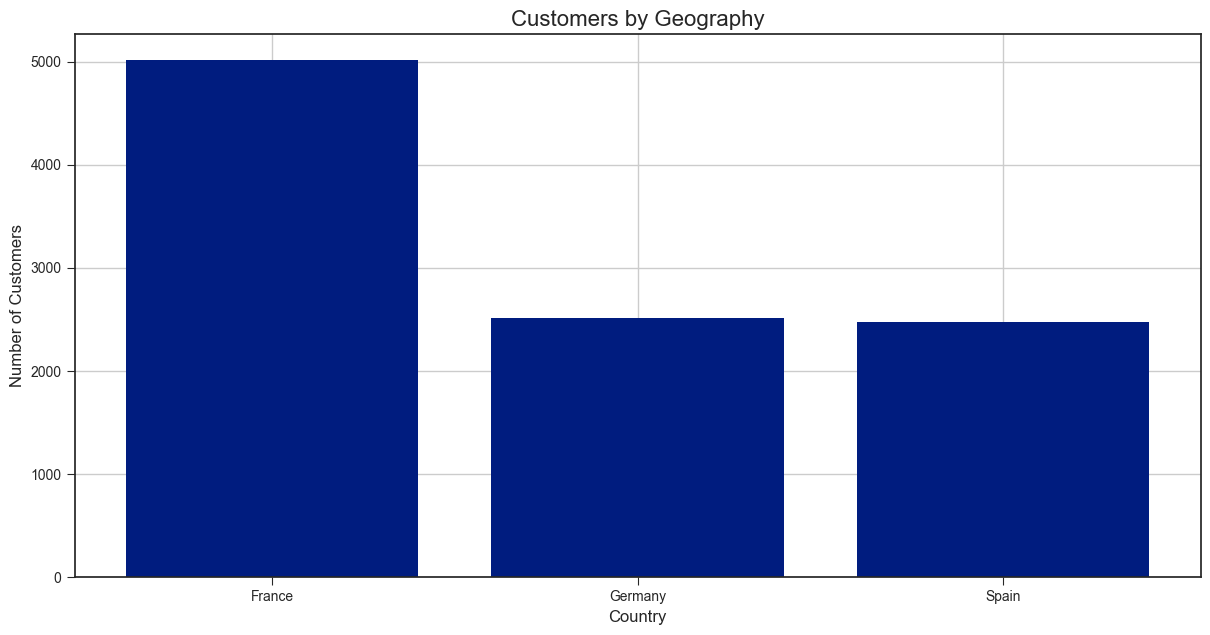

In [43]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
geo_counts = bank["Geography"].value_counts()

plt.bar(geo_counts.index, geo_counts.values)
plt.grid(True)
plt.style.use('seaborn-v0_8-ticks')
plt.tight_layout()
plt.xlabel("Country")
plt.ylabel("Number of Customers")
plt.title("Customers by Geography")
plt.show()

In [20]:
print(plt.style.available)

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


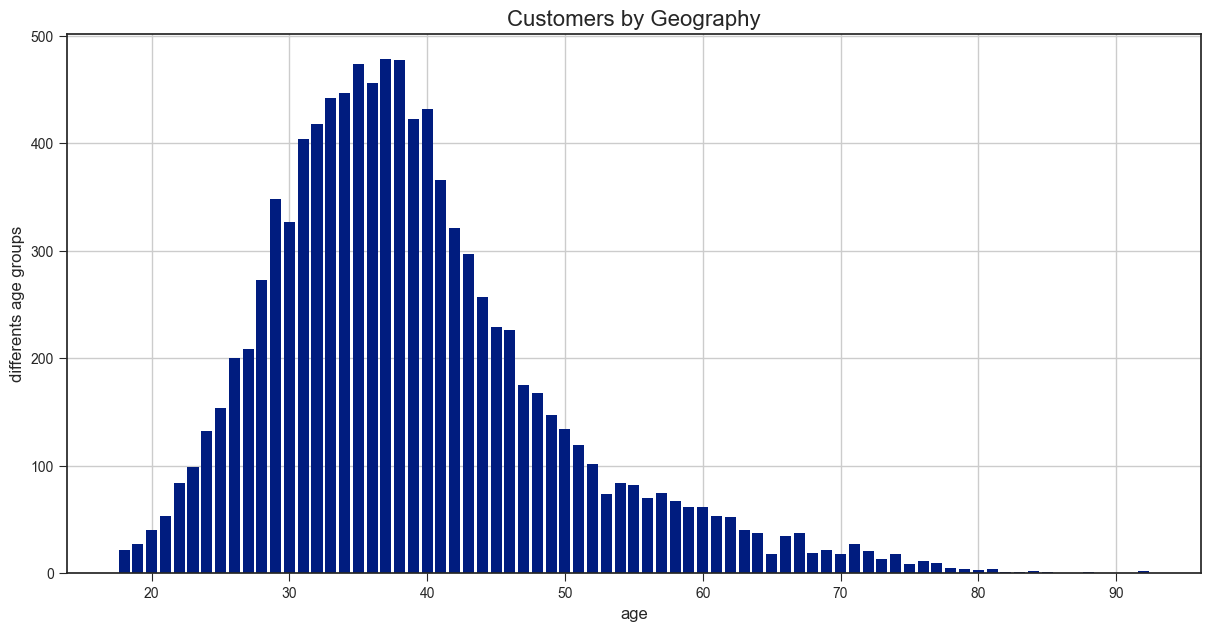

In [40]:
age_counts = bank["Age"].value_counts()
plt.figure(figsize=(12,6))   # increase graph size (width, height)
plt.bar(age_counts.index, age_counts.values)
plt.grid(True)
plt.style.use( 'seaborn-v0_8-ticks')
plt.tight_layout()
plt.xlabel("age")
plt.ylabel("differents age groups")
plt.title("Customers by Geography")
plt.show()

In [46]:
bank['NumOfProducts'].value_counts()

NumOfProducts
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64

Text(-37.75, 0.5, 'y label')

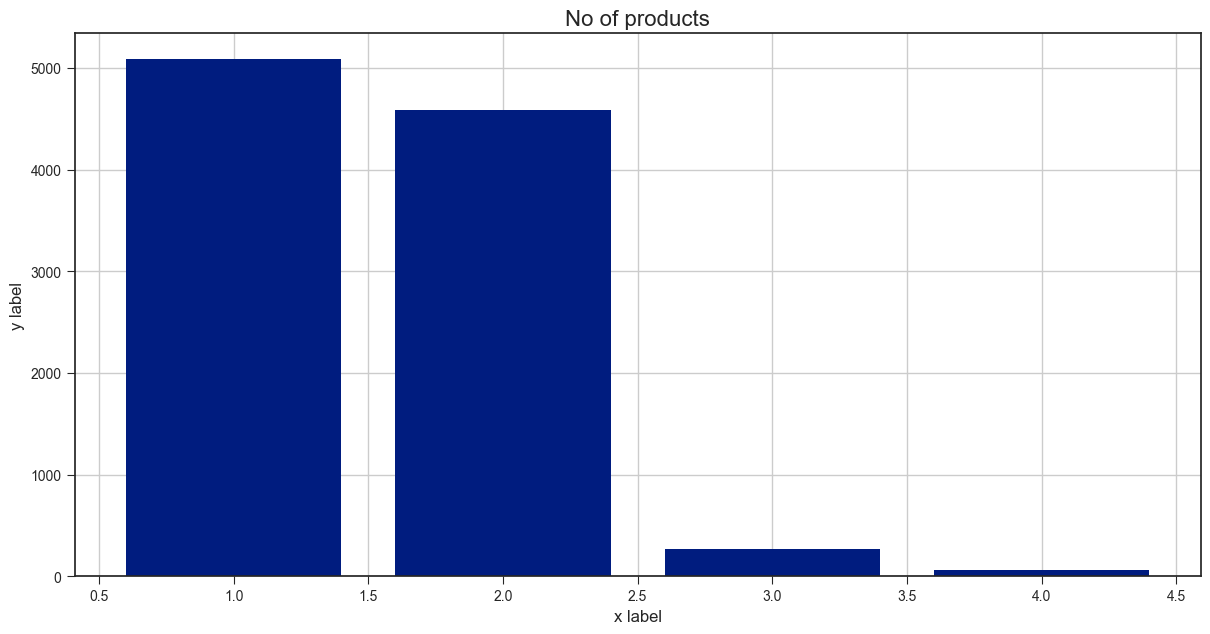

In [48]:
products_counts=bank['NumOfProducts'].value_counts()
plt.figure(figsize=(12,6))
plt.bar(products_counts.index,products_counts.values)
plt.grid(True)
plt.tight_layout()
plt.title("No of products")
plt.xlabel("x label")
plt.ylabel("y label")

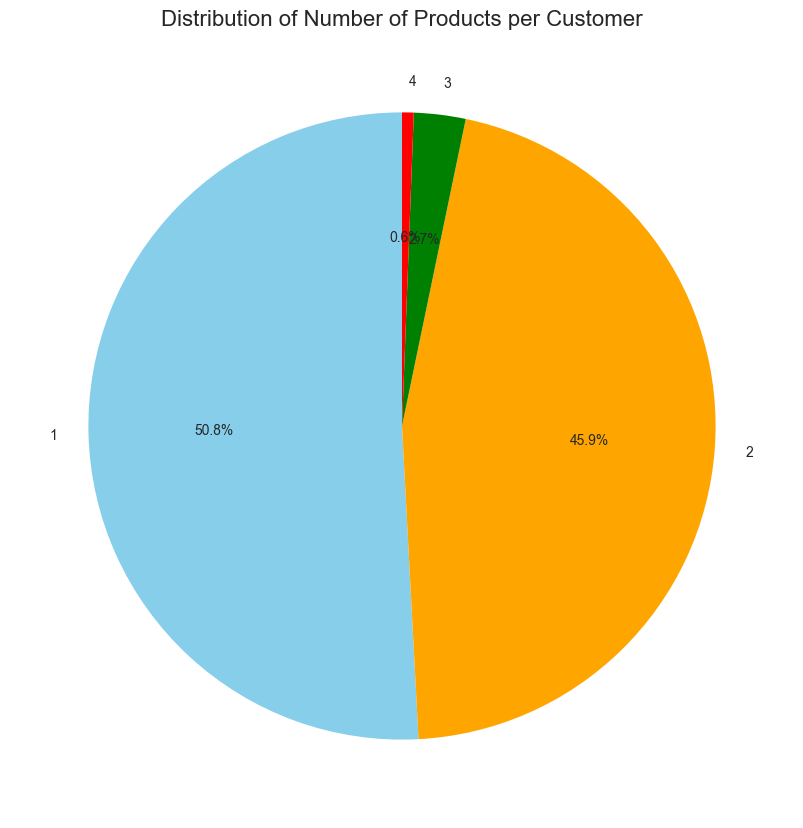

In [49]:
import matplotlib.pyplot as plt

# Count of customers by number of products
products_counts = bank['NumOfProducts'].value_counts().sort_index()

plt.figure(figsize=(8,8))  # make it square for pie chart

plt.pie(
    products_counts.values,          # numeric values
    labels=products_counts.index,    # product numbers as labels
    autopct="%1.1f%%",               # show percentage with 1 decimal
    startangle=90,                   # rotate chart for better start position
    colors=['skyblue','orange','green','red']  # optional colors
)

plt.title("Distribution of Number of Products per Customer")
plt.show()

In [50]:
 bank['NumOfProducts'].value_counts()

NumOfProducts
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64